c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew
📊 HEBREW DEPENDENCE PLOT - CLEANED DATA

📂 Loading cleaned data...
✅ Loaded cleaned data from: C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv
   Total samples: 1000

📝 Using columns:
   Text column: clean_text
   Label column: label

📝 Sample cleaned text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים ...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9643
   Test Accuracy: 0.8133
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[DEBUG] Looking for font for language: Hebrew
[DEBUG] Trying language-specific fonts: ['NotoSansHebrew-Regular.ttf', 'NotoSansHebrew-Varia

RuntimeError: Unable to generate SHAP scatter plot.
too many indices for array

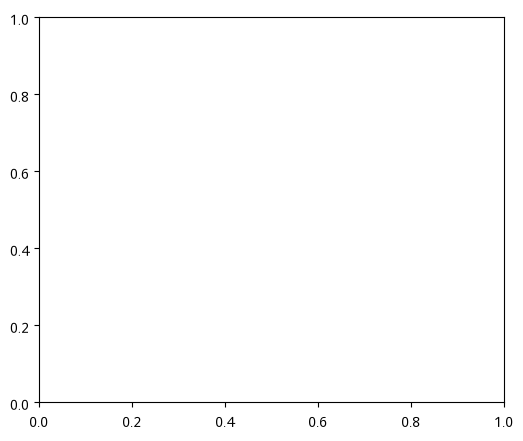

In [1]:
# ============================================================
# HEBREW DEPENDENCE PLOT - CLEANED DATA
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import scatter
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT - CLEANED DATA")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

# Load cleaned data
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data from: {file_path}")
    print(f"   Total samples: {len(df)}")
except FileNotFoundError:
    print(f"⚠️ File not found: {file_path}")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    # Use first 500 rows for speed
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

# Identify columns
text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"\n📝 Using columns:")
print(f"   Text column: {text_col}")
print(f"   Label column: {label_col}")

# Show sample
sample_text = df[text_col].iloc[0] if len(df) > 0 else ""
print(f"\n📝 Sample cleaned text:")
print(f"   {sample_text[:100]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

# Ensure labels are integers
if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

# Drop rows with empty text
df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='word',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

# Get a VIOLENCE sample
violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: GET SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES")
print("="*80)

# Vectorize the sample
vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

# Get SHAP values
shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

# Sort by absolute SHAP value
sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]
sorted_data = present_data[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("📊 DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

print(f"\n📊 Top feature: '{top_feature}'")
print(f"   SHAP value: {sorted_shap[0]:+.4f}")
print("-"*60)

print("\n🎨 Generating RTL Dependence Plot...")
print("   Shows how the feature value affects its SHAP contribution")
print("   X-axis: Feature value")
print("   Y-axis: SHAP value (contribution)")

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("\n📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if shap_values_all:
    shap_values_all = np.array(shap_values_all)
    data_all = np.array(data_all)
    labels_all = np.array(labels_all)
    
    # Create SHAP Explanation for dependence plot
    shap_exp_dependence = shap.Explanation(
        values=shap_values_all,
        base_values=shap_explainer.expected_value if hasattr(shap_explainer, 'expected_value') else 0,
        data=data_all,
        feature_names=feature_names
    )
    
    # Generate RTL Dependence Plot using scatter (which is dependence in RTL)
    print("\n🎨 Generating RTL Dependence Plot...")
    print("   Color = Feature value (red = high, blue = low)")
    print("   ⚪ Points show relationship between feature value and SHAP impact")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_dependence,
        prediction_label=class_names[1],
        plot_fn=scatter,
        max_features=1,
        features=data_all  # Pass features for dependence plot
    )
    plt.show()
    
    print("\n✅ Dependence plot complete!")
    
    # ============================================================
    # STEP 8: INTERPRETATION
    # ============================================================
    
    print("\n" + "="*80)
    print("📊 INTERPRETATION")
    print("="*80)
    
    # Get SHAP values for the top feature across all samples
    top_feature_shap = shap_values_all[:, top_feature_idx]
    top_feature_data = data_all[:, top_feature_idx]
    
    # Correlation
    correlation = np.corrcoef(top_feature_data, top_feature_shap)[0, 1]
    
    print(f"\n📊 Feature: '{top_feature}'")
    print(f"   Correlation with SHAP: {correlation:.3f}")
    print(f"   Mean SHAP value: {np.mean(top_feature_shap):+.4f}")
    print(f"   Positive SHAP in {np.mean(top_feature_shap > 0)*100:.1f}% of samples")
    
    if correlation > 0.3:
        print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
    elif correlation < -0.3:
        print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
    else:
        print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")
    
    # Check if feature is more important for VIOLENCE
    violence_shap = top_feature_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
    not_shap = top_feature_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []
    
    if len(violence_shap) > 0 and len(not_shap) > 0:
        print(f"\n   VIOLENCE samples: {np.mean(violence_shap):+.4f}")
        print(f"   NOT samples:      {np.mean(not_shap):+.4f}")
        
        if np.mean(violence_shap) > np.mean(not_shap):
            print(f"   ✅ Feature is more positive in VIOLENCE samples")
        else:
            print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ DEPENDENCE PLOT COMPLETE!")
print("="*80)


📊 DEPENDENCE PLOT

📊 Top feature: 'לך'
   SHAP value: +0.2069
   Color by: 'כמו'
------------------------------------------------------------

🎨 Generating Dependence Plot...
   X-axis: Feature value
   Y-axis: SHAP value (contribution)
   Color: Second feature value (red = high, blue = low)

📊 Computing SHAP values for 100 samples...


findfont: Failed to find font weight bold, now using 400.


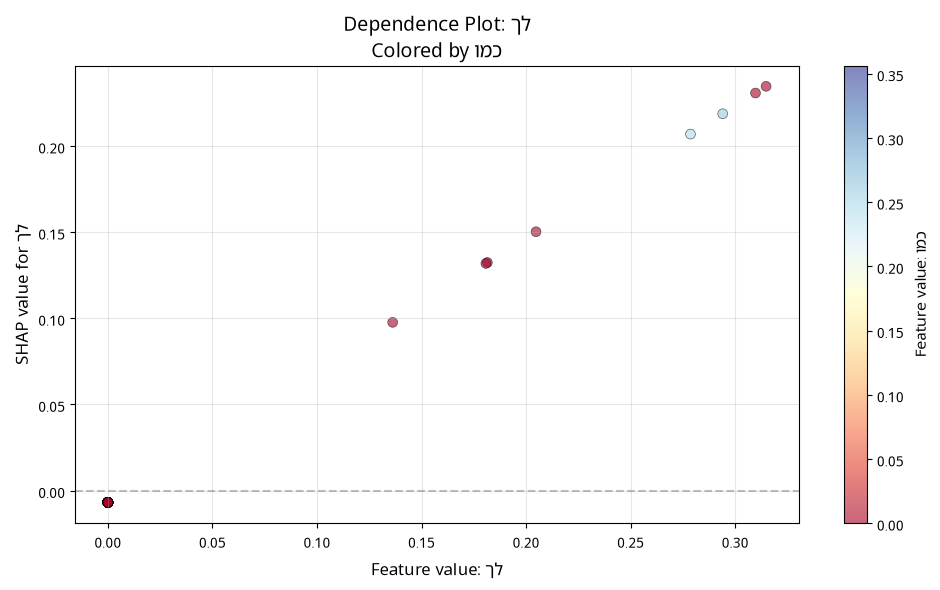


✅ Dependence plot complete!

📊 INTERPRETATION

📊 Feature: 'לך'
   Correlation with SHAP: 1.000
   Mean SHAP value: +0.0077
   Positive SHAP in 8.0% of samples
   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)

   VIOLENCE samples: +0.0225
   NOT samples:      +0.0057
   ✅ Feature is more positive in VIOLENCE samples


In [2]:
# ── DEPENDENCE PLOT - USING MATPLOTLIB DIRECTLY ────────────────────────────

print("\n" + "="*80)
print("📊 DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Top feature: '{top_feature}'")
print(f"   SHAP value: {sorted_shap[0]:+.4f}")
print(f"   Color by: '{second_feature}'")
print("-"*60)

print("\n🎨 Generating Dependence Plot...")
print("   X-axis: Feature value")
print("   Y-axis: SHAP value (contribution)")
print("   Color: Second feature value (red = high, blue = low)")

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("\n📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if shap_values_all:
    shap_values_all = np.array(shap_values_all)
    data_all = np.array(data_all)
    labels_all = np.array(labels_all)
    
    # Extract data for the two features
    feature1_data = data_all[:, top_feature_idx]
    feature1_shap = shap_values_all[:, top_feature_idx]
    feature2_data = data_all[:, second_feature_idx]
    
    # Create the dependence plot using matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot
    scatter_plot = ax.scatter(
        feature1_data,
        feature1_shap,
        c=feature2_data,
        cmap='RdYlBu',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )
    
    ax.set_xlabel(f'Feature value: {top_feature}', fontsize=12)
    ax.set_ylabel(f'SHAP value for {top_feature}', fontsize=12)
    ax.set_title(f'Dependence Plot: {top_feature}\nColored by {second_feature}', 
                 fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter_plot)
    cbar.set_label(f'Feature value: {second_feature}', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Dependence plot complete!")
    
    # ── INTERPRETATION ──────────────────────────────────────────────────────────
    
    print("\n" + "="*80)
    print("📊 INTERPRETATION")
    print("="*80)
    
    # Correlation
    correlation = np.corrcoef(feature1_data, feature1_shap)[0, 1]
    
    print(f"\n📊 Feature: '{top_feature}'")
    print(f"   Correlation with SHAP: {correlation:.3f}")
    print(f"   Mean SHAP value: {np.mean(feature1_shap):+.4f}")
    print(f"   Positive SHAP in {np.mean(feature1_shap > 0)*100:.1f}% of samples")
    
    if correlation > 0.3:
        print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
    elif correlation < -0.3:
        print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
    else:
        print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")
    
    # Check if feature is more important for VIOLENCE
    violence_shap = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
    not_shap = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []
    
    if len(violence_shap) > 0 and len(not_shap) > 0:
        print(f"\n   VIOLENCE samples: {np.mean(violence_shap):+.4f}")
        print(f"   NOT samples:      {np.mean(not_shap):+.4f}")
        
        if np.mean(violence_shap) > np.mean(not_shap):
            print(f"   ✅ Feature is more positive in VIOLENCE samples")
        else:
            print(f"   ✅ Feature is more negative in NOT samples")

📊 HEBREW DEPENDENCE PLOT WITH RTL EXPLANATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

🔧 Preparing data...

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[INFO] Font registered with matplotlib: Noto Sans Hebrew
[INFO] Loaded Hebrew font: NotoSansHebrew-Regular.ttf
[INFO] Font display name: Noto Sans Hebrew

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: NotoSansHebrew-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!

🎯 GETTING VIOLENCE SAMPLE

📝 VIOLENCE Sample:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

📊 COMPUTING SH

findfont: Failed to find font weight bold, now using 400.


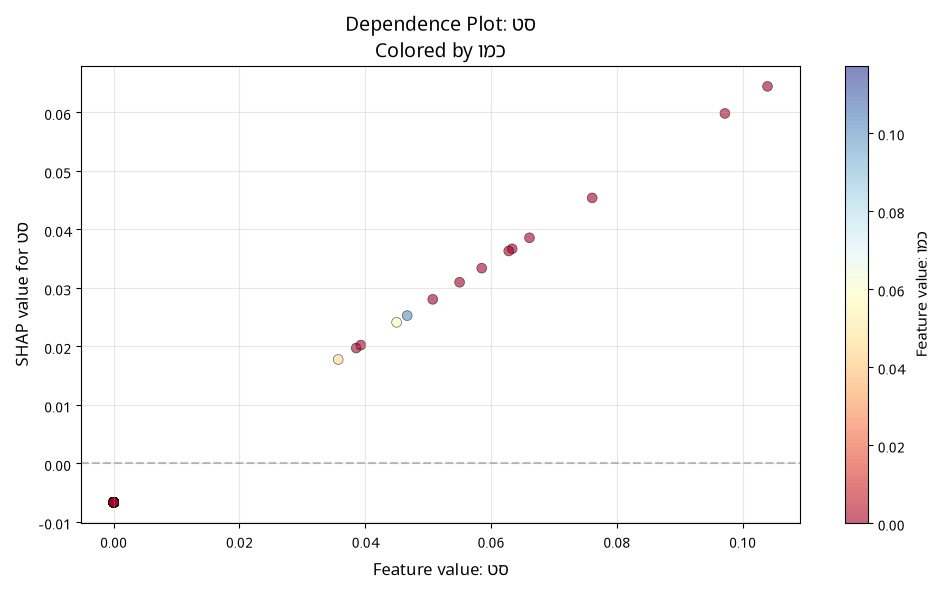


✅ Dependence plot complete!

📊 GENERATING EXPLANATIONS USING RTL EXPLAINER
[INFO] Translating 1 features in chunks of 20...

📊 Top Feature Analysis:
   Feature: סט
   English: Set
   Mean SHAP: -0.0009
   Std SHAP: +0.0151
   Positive SHAP: 14.0% of samples
   Negative SHAP: 86.0% of samples

🎨 Generating RTL Explanations...
------------------------------------------------------------

                            HEBREW SHAP EXPLANATIONS                            
                              Prediction: VIOLENCE                              

[INFO] No plot_fn provided. Skipping visualization.

[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: VIOLENCE
------------------------------------------------------------------------------------------------------------------------
     

In [3]:
# ============================================================
# HEBREW DEPENDENCE PLOT WITH RTL EXPLANATIONS
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import bar, waterfall, beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT WITH RTL EXPLANATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n🔧 Preparing data...")

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50  # Limit translations for speed
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: DEPENDENCE PLOT (Using Matplotlib)
# ============================================================

print("\n" + "="*80)
print("📊 DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Top feature: '{top_feature}'")
print(f"   SHAP value: {sorted_shap[0]:+.4f}")
print(f"   Color by: '{second_feature}'")
print("-"*60)

print("\n🎨 Generating Dependence Plot...")
print("   X-axis: Feature value")
print("   Y-axis: SHAP value (contribution)")
print("   Color: Second feature value (red = high, blue = low)")

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("\n📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if shap_values_all:
    shap_values_all = np.array(shap_values_all)
    data_all = np.array(data_all)
    labels_all = np.array(labels_all)
    
    # Extract data for the two features
    feature1_data = data_all[:, top_feature_idx]
    feature1_shap = shap_values_all[:, top_feature_idx]
    feature2_data = data_all[:, second_feature_idx]
    
    # Create the dependence plot using matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    scatter_plot = ax.scatter(
        feature1_data,
        feature1_shap,
        c=feature2_data,
        cmap='RdYlBu',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )
    
    ax.set_xlabel(f'Feature value: {top_feature}', fontsize=12)
    ax.set_ylabel(f'SHAP value for {top_feature}', fontsize=12)
    ax.set_title(f'Dependence Plot: {top_feature}\nColored by {second_feature}', 
                 fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter_plot)
    cbar.set_label(f'Feature value: {second_feature}', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Dependence plot complete!")

# ============================================================
# STEP 8: GET EXPLANATIONS USING RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("📊 GENERATING EXPLANATIONS USING RTL EXPLAINER")
print("="*80)

# We need to create a SHAP Explanation object for the top feature
# Create a new Explanation with the top feature only
top_feature_shap = shap_values_all[:, top_feature_idx]
top_feature_data = data_all[:, top_feature_idx]

shap_exp_single = shap.Explanation(
    values=top_feature_shap,
    base_values=np.mean(top_feature_shap),  # Use mean as base
    data=top_feature_data,
    feature_names=[top_feature]
)

# Translate feature names for the explanation
eng_feature_names = explainer_rtl._translate_features([top_feature])

# Rebuild with English names
shap_exp_eng = shap.Explanation(
    values=top_feature_shap,
    base_values=np.mean(top_feature_shap),
    data=top_feature_data,
    feature_names=eng_feature_names
)

print(f"\n📊 Top Feature Analysis:")
print("="*60)
print(f"   Feature: {top_feature}")
print(f"   English: {eng_feature_names[0] if eng_feature_names else top_feature}")
print(f"   Mean SHAP: {np.mean(top_feature_shap):+.4f}")
print(f"   Std SHAP: {np.std(top_feature_shap):+.4f}")
print(f"   Positive SHAP: {np.mean(top_feature_shap > 0)*100:.1f}% of samples")
print(f"   Negative SHAP: {np.mean(top_feature_shap < 0)*100:.1f}% of samples")

# Get explanations from RTL explainer
print(f"\n🎨 Generating RTL Explanations...")
print("-"*60)

# Create a SHAP Explanation for the top feature
# We'll use the run_full_analysis with bar plot for explanation
shap_exp_for_rtl = shap.Explanation(
    values=top_feature_shap,
    base_values=np.mean(top_feature_shap),
    data=top_feature_data,
    feature_names=[top_feature]
)

# Generate explanation using the RTL explainer
explainer_rtl.run_full_analysis(
    shap_values=shap_exp_for_rtl,
    prediction_label=class_names[1],
    plot_fn=None,  # No plot, just explanations
    max_features=1,
    sample_text=sample_text
)

# ============================================================
# STEP 9: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation
correlation = np.corrcoef(feature1_data, feature1_shap)[0, 1]

print(f"\n📊 Feature: '{top_feature}'")
print(f"   English: {eng_feature_names[0] if eng_feature_names else top_feature}")
print(f"   Correlation with SHAP: {correlation:.3f}")
print(f"   Mean SHAP value: {np.mean(feature1_shap):+.4f}")
print(f"   Positive SHAP in {np.mean(feature1_shap > 0)*100:.1f}% of samples")

if correlation > 0.3:
    print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
elif correlation < -0.3:
    print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
else:
    print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")

# Check if feature is more important for VIOLENCE
violence_shap = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

if len(violence_shap) > 0 and len(not_shap) > 0:
    print(f"\n📊 Class-wise Analysis:")
    print(f"   VIOLENCE samples: {np.mean(violence_shap):+.4f} (n={len(violence_shap)})")
    print(f"   NOT samples:      {np.mean(not_shap):+.4f} (n={len(not_shap)})")
    
    if np.mean(violence_shap) > np.mean(not_shap):
        print(f"   ✅ Feature is more positive in VIOLENCE samples")
    else:
        print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ DEPENDENCE PLOT WITH RTL EXPLANATIONS COMPLETE!")
print("="*80)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew
📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

📝 Sample text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[DEBUG] Looking for font for language: Hebrew
[DEBUG] Trying language-specific fonts: ['NotoSansHebrew-Regular.ttf', 'NotoSansHebrew-VariableFont_wdth,wght.ttf', 'NotoSerifHebrew-Regular.ttf', 'NotoSerifHebrew-VariableFont_wdth,wght.ttf', 'Arial.ttf', 'TimesNewRoman.ttf', 'EzraSI

findfont: Failed to find font weight bold, now using 400.


✅ Computed SHAP values for 100 samples

📊 CHOOSING FEATURES FOR DEPENDENCE PLOT

📊 Selected features:
   Main feature: 'סט' (SHAP: +0.0612)
   Color by: 'כמו'
------------------------------------------------------------

📊 CREATING DEPENDENCE PLOT DATA

📊 Using 5 features:
   1. סט (mean SHAP: +0.0003)
   2. כמו (mean SHAP: +0.0015)
   3. זכ (mean SHAP: -0.0000)
   4. זען (mean SHAP: -0.0010)
   5.  קש (mean SHAP: +0.0005)
------------------------------------------------------------

📊 SHAP Explanation created:
   Values shape: (100, 5)
   Feature names: ['סט', 'כמו', 'זכ', 'זען', ' קש']

🎨 RUNNING RTL EXPLAINER WITH DEPENDENCE PLOT

📋 Flow:
   1. Hebrew dependence plot will be shown
   2. You'll be asked: How many features to explain in Hebrew?
   3. Hebrew explanation will be generated
   4. You'll be asked: Would you like to see the plot in English?
   5. English dependence plot (with translated feature names) will be shown
   6. You'll be asked: Would you like explanation in Englis

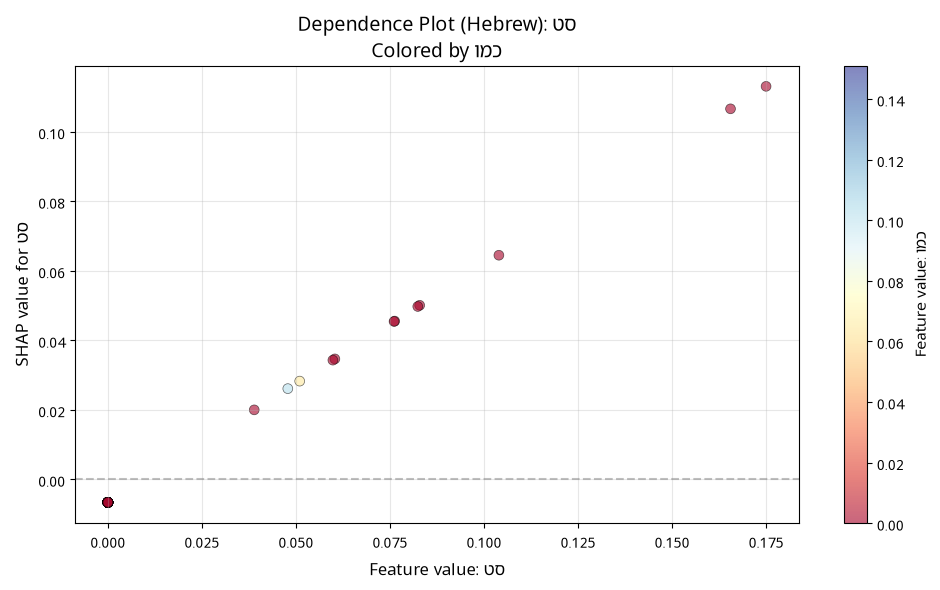


[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: VIOLENCE
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
--------------------------------------------------

Feature: סט | Value: +0.0003
----------------------------------------
המאפיין "סט" משפיע חיובית על החזוי "VIOLENCE" משום שבהקשרים מסוימים, המילה "סט" יכולה להתייחס לקבוצה או לחבורה, ובמצבים מסוימים, קבוצות או חבורות יכולות להיות מעורבות באלימות. כתוצאה מכך, הופעת המאפיין "סט" בטקסט יכולה לתרום לחזוי של אלימות, ולכן הוא משפיע חיובית על החזוי "VIOLENCE".
----------------------------------------


[INFO] Generating English plot...

[INF

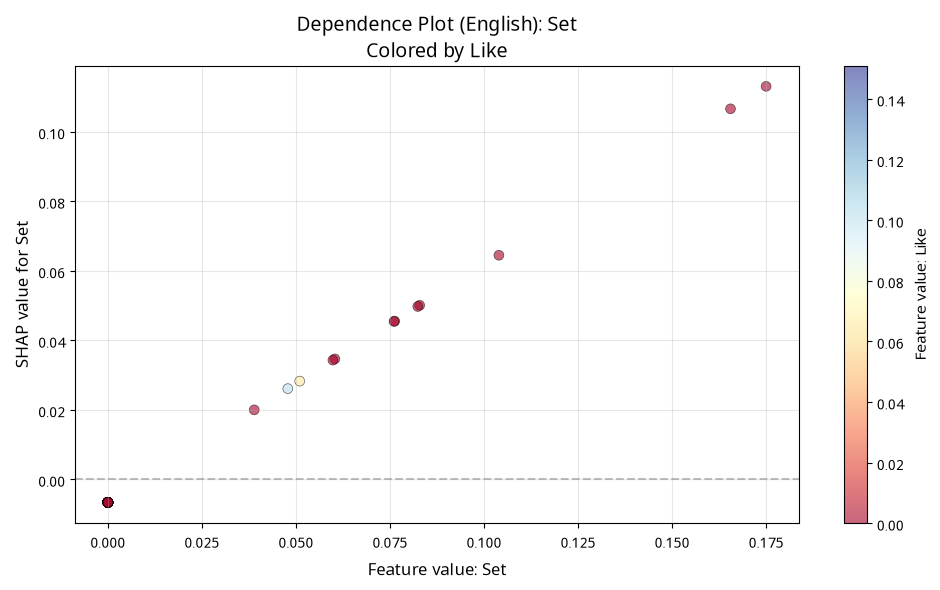


                              ENGLISH EXPLANATIONS                              

Translated Sample: נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                              PREDICTION: Violence                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: סט | Value: +0.0003
----------------------------------------
The Hebrew feature 'סט' (SHAP value: +0.0003) has a minor positive impact on the model's prediction of 'VIOLENCE', suggesting that the presence of this feature slightly increases the likelihood of violence. Although the effect is negligible, it may be attributed to the featur

In [2]:
# ============================================================
# HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS - COMPLETE TEST
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import bar, waterfall, beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR SAMPLE")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CHOOSE FEATURES FOR DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CHOOSING FEATURES FOR DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Selected features:")
print(f"   Main feature: '{top_feature}' (SHAP: {sorted_shap[0]:+.4f})")
print(f"   Color by: '{second_feature}'")
print("-"*60)

# Get data for selected features
feature1_data = data_all[:, top_feature_idx]
feature1_shap = shap_values_all[:, top_feature_idx]
feature2_data = data_all[:, second_feature_idx]

# ============================================================
# STEP 9: CREATE DEPENDENCE PLOT DATA
# ============================================================

print("\n" + "="*80)
print("📊 CREATING DEPENDENCE PLOT DATA")
print("="*80)

# Use top 5 features for the SHAP Explanation
num_features_for_plot = min(5, len(sorted_features))
top_features_for_plot = sorted_features[:num_features_for_plot]
top_indices_for_plot = [feature_names.index(f) for f in top_features_for_plot]

# Get SHAP values for these features
top_shap_for_plot = shap_values_all[:, top_indices_for_plot]
top_data_for_plot = data_all[:, top_indices_for_plot]
top_names_for_plot = top_features_for_plot

print(f"\n📊 Using {num_features_for_plot} features:")
for i, name in enumerate(top_names_for_plot):
    mean_shap = np.mean(shap_values_all[:, feature_names.index(name)])
    print(f"   {i+1}. {name} (mean SHAP: {mean_shap:+.4f})")
print("-"*60)

# Create SHAP Explanation with multiple features
shap_exp_multi = shap.Explanation(
    values=top_shap_for_plot,
    base_values=np.mean(top_shap_for_plot, axis=0),
    data=top_data_for_plot,
    feature_names=top_names_for_plot
)

print(f"\n📊 SHAP Explanation created:")
print(f"   Values shape: {shap_exp_multi.values.shape}")
print(f"   Feature names: {shap_exp_multi.feature_names}")

# ============================================================
# STEP 10: RUN RTL EXPLAINER WITH DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("🎨 RUNNING RTL EXPLAINER WITH DEPENDENCE PLOT")
print("="*80)

print("\n📋 Flow:")
print("   1. Hebrew dependence plot will be shown")
print("   2. You'll be asked: How many features to explain in Hebrew?")
print("   3. Hebrew explanation will be generated")
print("   4. You'll be asked: Would you like to see the plot in English?")
print("   5. English dependence plot (with translated feature names) will be shown")
print("   6. You'll be asked: Would you like explanation in English?")
print("   7. English explanation will be generated")
print("-"*60)

# This will follow the full flow:
# RTL Plot → RTL Explanation → English Plot → English Explanation
try:
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_multi,
        prediction_label=class_names[1],
        plot_fn=None,  # ← No plot function = dependence plot
        max_features=5,
        sample_text=sample_text,
        allow_positive_negative_split=True,
        features=top_data_for_plot  # ← Pass features for dependence plot
    )
except Exception as e:
    print(f"[WARNING] Dependence plot failed: {e}")
    print("\n📌 Falling back to direct explanation...")
    
    # ============================================================
    # FALLBACK: Direct Explanations Without Plot
    # ============================================================
    
    print("\n" + "="*80)
    print("📊 DIRECT EXPLANATIONS (FALLBACK)")
    print("="*80)
    
    # Translate sample
    eng_sample = explainer_rtl._translate_sample(sample_text)
    eng_label = explainer_rtl._translate_label(class_names[1])
    
    print(f"\n📝 Sample Translation:")
    print(f"   {eng_sample}")
    print("-"*60)
    
    for i, feat in enumerate(top_names_for_plot[:3]):
        eng_feature = explainer_rtl._translate_features([feat])[0]
        shap_val = np.mean(shap_values_all[:, feature_names.index(feat)])
        
        print(f"\n{i+1}. Feature: {feat}")
        print(f"   English: {eng_feature}")
        print(f"   Mean SHAP: {shap_val:+.4f}")
        
        # Get English explanation
        try:
            prompt = explainer_rtl._eng_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1],
                eng_translation=eng_label
            )
            response = explainer_rtl._invoke_llm(prompt)
            print(f"\n   📝 English Explanation:")
            print(f"   {response}")
        except Exception as e2:
            print(f"   ⚠️ Could not generate English explanation: {e2}")
        
        # Get Hebrew explanation
        try:
            prompt = explainer_rtl._rtl_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1]
            )
            response = explainer_rtl._invoke_llm(prompt)
            fixed_response = explainer_rtl._fix_for_terminal(response)
            print(f"\n   📝 Hebrew Explanation:")
            print(f"   {fixed_response}")
        except Exception as e3:
            print(f"   ⚠️ Could not generate Hebrew explanation: {e3}")
        
        print("-"*60)

# ============================================================
# STEP 11: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation
correlation = np.corrcoef(feature1_data, feature1_shap)[0, 1]

print(f"\n📊 Feature: '{top_feature}'")
print(f"   Mean SHAP value: {np.mean(feature1_shap):+.4f}")
print(f"   Correlation with SHAP: {correlation:.3f}")
print(f"   Positive SHAP in {np.mean(feature1_shap > 0)*100:.1f}% of samples")

if correlation > 0.3:
    print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
elif correlation < -0.3:
    print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
else:
    print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")

# Class-wise analysis
violence_shap = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

if len(violence_shap) > 0 and len(not_shap) > 0:
    print(f"\n📊 Class-wise Analysis:")
    print(f"   VIOLENCE samples: {np.mean(violence_shap):+.4f} (n={len(violence_shap)})")
    print(f"   NOT samples:      {np.mean(not_shap):+.4f} (n={len(not_shap)})")
    
    if np.mean(violence_shap) > np.mean(not_shap):
        print(f"   ✅ Feature is more positive in VIOLENCE samples")
    else:
        print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)
print("\n💡 Summary:")
print("   • Hebrew dependence plot shown first")
print("   • English dependence plot shown when requested")
print("   • Hebrew and English explanations generated")
print("   • All translations use the RTL explainer")

In [1]:
# ============================================================
# HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS - COMPLETE TEST
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import bar, waterfall, beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR SAMPLE")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CHOOSE FEATURES FOR DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CHOOSING FEATURES FOR DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Selected features:")
print(f"   Main feature: '{top_feature}' (SHAP: {sorted_shap[0]:+.4f})")
print(f"   Color by: '{second_feature}'")
print("-"*60)

# Get data for selected features
feature1_data = data_all[:, top_feature_idx]
feature1_shap = shap_values_all[:, top_feature_idx]
feature2_data = data_all[:, second_feature_idx]

# ============================================================
# STEP 9: CREATE DEPENDENCE PLOT DATA
# ============================================================

print("\n" + "="*80)
print("📊 CREATING DEPENDENCE PLOT DATA")
print("="*80)

# Use top 5 features for the SHAP Explanation
num_features_for_plot = min(5, len(sorted_features))
top_features_for_plot = sorted_features[:num_features_for_plot]
top_indices_for_plot = [feature_names.index(f) for f in top_features_for_plot]

# Get SHAP values for these features
top_shap_for_plot = shap_values_all[:, top_indices_for_plot]
top_data_for_plot = data_all[:, top_indices_for_plot]
top_names_for_plot = top_features_for_plot

print(f"\n📊 Using {num_features_for_plot} features:")
for i, name in enumerate(top_names_for_plot):
    mean_shap = np.mean(shap_values_all[:, feature_names.index(name)])
    print(f"   {i+1}. {name} (mean SHAP: {mean_shap:+.4f})")
print("-"*60)

# Create SHAP Explanation with multiple features
shap_exp_multi = shap.Explanation(
    values=top_shap_for_plot,
    base_values=np.mean(top_shap_for_plot, axis=0),
    data=top_data_for_plot,
    feature_names=top_names_for_plot
)

print(f"\n📊 SHAP Explanation created:")
print(f"   Values shape: {shap_exp_multi.values.shape}")
print(f"   Feature names: {shap_exp_multi.feature_names}")

# ============================================================
# STEP 10: RUN RTL EXPLAINER WITH DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("🎨 RUNNING RTL EXPLAINER WITH DEPENDENCE PLOT")
print("="*80)

print("\n📋 Flow:")
print("   1. Hebrew dependence plot will be shown")
print("   2. You'll be asked: How many features to explain in Hebrew?")
print("   3. Hebrew explanation will be generated")
print("   4. You'll be asked: Would you like to see the plot in English?")
print("   5. English dependence plot (with translated feature names) will be shown")
print("   6. You'll be asked: Would you like explanation in English?")
print("   7. English explanation will be generated")
print("-"*60)

# This will follow the full flow:
# RTL Plot → RTL Explanation → English Plot → English Explanation
try:
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_multi,
        prediction_label=class_names[1],
        plot_fn=None,  # ← No plot function = dependence plot
        max_features=5,
        sample_text=sample_text,
        allow_positive_negative_split=True,
        features=top_data_for_plot  # ← Pass features for dependence plot
    )
except Exception as e:
    print(f"[WARNING] Dependence plot failed: {e}")
    print("\n📌 Falling back to direct explanation...")
    
    # ============================================================
    # FALLBACK: Direct Explanations Without Plot
    # ============================================================
    
    print("\n" + "="*80)
    print("📊 DIRECT EXPLANATIONS (FALLBACK)")
    print("="*80)
    
    # Translate sample
    eng_sample = explainer_rtl._translate_sample(sample_text)
    eng_label = explainer_rtl._translate_label(class_names[1])
    
    print(f"\n📝 Sample Translation:")
    print(f"   {eng_sample}")
    print("-"*60)
    
    for i, feat in enumerate(top_names_for_plot[:3]):
        eng_feature = explainer_rtl._translate_features([feat])[0]
        shap_val = np.mean(shap_values_all[:, feature_names.index(feat)])
        
        print(f"\n{i+1}. Feature: {feat}")
        print(f"   English: {eng_feature}")
        print(f"   Mean SHAP: {shap_val:+.4f}")
        
        # Get English explanation
        try:
            prompt = explainer_rtl._eng_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1],
                eng_translation=eng_label
            )
            response = explainer_rtl._invoke_llm(prompt)
            print(f"\n   📝 English Explanation:")
            print(f"   {response}")
        except Exception as e2:
            print(f"   ⚠️ Could not generate English explanation: {e2}")
        
        # Get Hebrew explanation
        try:
            prompt = explainer_rtl._rtl_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1]
            )
            response = explainer_rtl._invoke_llm(prompt)
            fixed_response = explainer_rtl._fix_for_terminal(response)
            print(f"\n   📝 Hebrew Explanation:")
            print(f"   {fixed_response}")
        except Exception as e3:
            print(f"   ⚠️ Could not generate Hebrew explanation: {e3}")
        
        print("-"*60)

# ============================================================
# STEP 11: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation
correlation = np.corrcoef(feature1_data, feature1_shap)[0, 1]

print(f"\n📊 Feature: '{top_feature}'")
print(f"   Mean SHAP value: {np.mean(feature1_shap):+.4f}")
print(f"   Correlation with SHAP: {correlation:.3f}")
print(f"   Positive SHAP in {np.mean(feature1_shap > 0)*100:.1f}% of samples")

if correlation > 0.3:
    print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
elif correlation < -0.3:
    print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
else:
    print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")

# Class-wise analysis
violence_shap = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

if len(violence_shap) > 0 and len(not_shap) > 0:
    print(f"\n📊 Class-wise Analysis:")
    print(f"   VIOLENCE samples: {np.mean(violence_shap):+.4f} (n={len(violence_shap)})")
    print(f"   NOT samples:      {np.mean(not_shap):+.4f} (n={len(not_shap)})")
    
    if np.mean(violence_shap) > np.mean(not_shap):
        print(f"   ✅ Feature is more positive in VIOLENCE samples")
    else:
        print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)
print("\n💡 Summary:")
print("   • Hebrew dependence plot shown first")
print("   • English dependence plot shown when requested")
print("   • Hebrew and English explanations generated")
print("   • All translations use the RTL explainer")

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew
📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

📝 Sample text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[DEBUG] Looking for font for language: Hebrew
[DEBUG] Trying language-specific fonts: ['NotoSansHebrew-Regular.ttf', 'NotoSansHebrew-VariableFont_wdth,wght.ttf', 'NotoSerifHebrew-Regular.ttf', 'NotoSerifHebrew-VariableFont_wdth,wght.ttf', 'Arial.ttf', 'TimesNewRoman.ttf', 'EzraSI

📊 HEBREW SCATTER PLOT WITH RTL TRANSLATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

📝 Sample text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[INFO] Font registered with matplotlib: Noto Sans Hebrew
[INFO] Loaded Hebrew font: NotoSansHebrew-Regular.ttf
[INFO] Font display name: Noto Sans Hebrew

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: NotoSansHebrew-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!

🎯 GETTING VIOLENCE SAMPLE

📝 VIOLENCE Sample:
   נר

findfont: Failed to find font weight bold, now using 400.


✅ Computed SHAP values for 100 samples

📊 CHOOSING FEATURES FOR SCATTER PLOT

📊 Selected features for scatter plot:
   Feature 1: 'סט' (SHAP: +0.0612)
   Feature 2: 'כמו' (SHAP: +0.0556)
------------------------------------------------------------

📊 CREATING SCATTER PLOT DATA

📊 Scatter plot data created:
   Values shape: (100, 2)
   Feature names: ['סט', 'כמו']
------------------------------------------------------------

📊 SCATTER PLOT - HEBREW VERSION

🎨 Generating Hebrew Scatter Plot...
   Shows relationship between two features
   X-axis: SHAP value for feature 1
   Y-axis: SHAP value for feature 2
   Color: Feature 1 value (red = high, blue = low)
------------------------------------------------------------


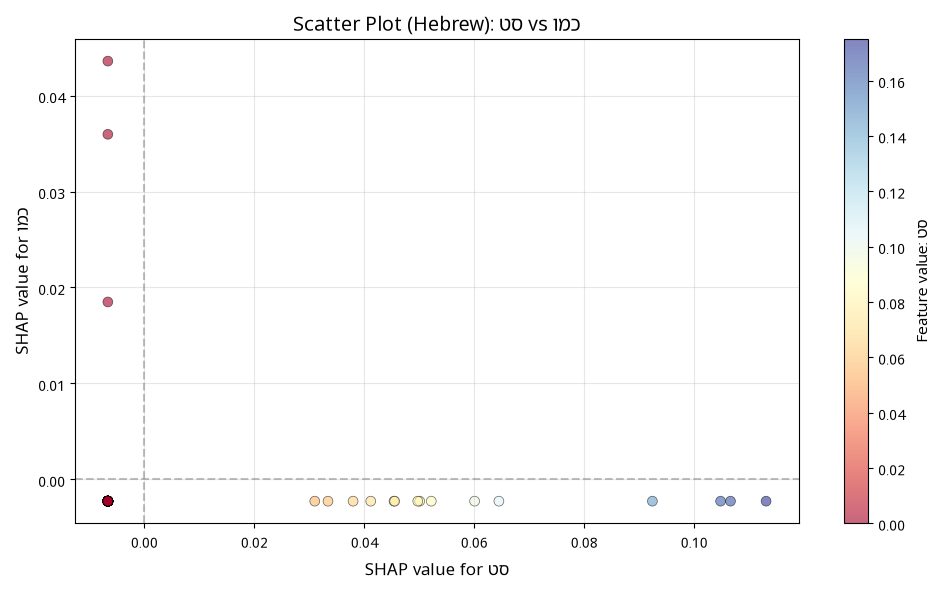


✅ Hebrew scatter plot complete!

📊 SCATTER PLOT - ENGLISH VERSION
[INFO] Translating 1 features in chunks of 20...
[INFO] Translating 1 features in chunks of 20...

📊 Translated features:
   Feature 1: 'Set' (original: סט)
   Feature 2: 'Like' (original: כמו)
------------------------------------------------------------

🎨 Generating English Scatter Plot...
   Shows relationship between two features
   X-axis: SHAP value for feature 1
   Y-axis: SHAP value for feature 2
   Color: Feature 1 value (red = high, blue = low)
------------------------------------------------------------


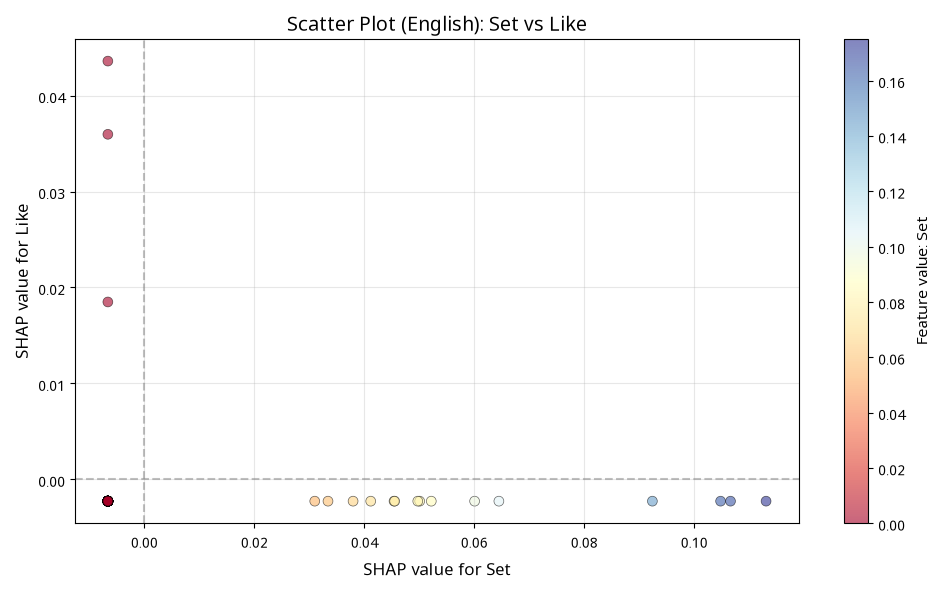


✅ English scatter plot complete!

📊 GENERATING EXPLANATIONS

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Hebrew Text:
  נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים

English Translation:
  It seems to me that the case reminds you of your good old days in the hills where you were a racist terrorist like them, isn't there a bit of nostalgia in hard times
--------------------------------------------------------------------------------

📝 Sample Translation:
   It seems to me that the case reminds you of your good old days in the hills where you were a racist terrorist like them, isn't there a bit of nostalgia in hard times
------------------------------------------------------------

1. Feature: סט
   English: Set
   Mean SHAP: +0.0036

   📝 English Explanation:
   The Hebrew feature 'סט' (SHAP value: +0.0036) has a slight positive impact on the model's prediction of 'VIOLENCE', suggesting that the presence of this feature

In [3]:
# ============================================================
# HEBREW SCATTER PLOT WITH RTL TRANSLATIONS - COMPLETE TEST
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import scatter, bar, waterfall, beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW SCATTER PLOT WITH RTL TRANSLATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR SAMPLE")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CHOOSE FEATURES FOR SCATTER PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CHOOSING FEATURES FOR SCATTER PLOT")
print("="*80)

# Choose top 2 features for scatter plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Selected features for scatter plot:")
print(f"   Feature 1: '{top_feature}' (SHAP: {sorted_shap[0]:+.4f})")
print(f"   Feature 2: '{second_feature}' (SHAP: {sorted_shap[1] if len(sorted_shap) > 1 else 0:+.4f})")
print("-"*60)

# ============================================================
# STEP 9: CREATE SCATTER PLOT DATA
# ============================================================

print("\n" + "="*80)
print("📊 CREATING SCATTER PLOT DATA")
print("="*80)

# Get data for the two features
feature1_data = data_all[:, top_feature_idx]
feature1_shap = shap_values_all[:, top_feature_idx]
feature2_data = data_all[:, second_feature_idx]
feature2_shap = shap_values_all[:, second_feature_idx]

# Create SHAP Explanation with 2 features for scatter plot
scatter_shap = shap.Explanation(
    values=shap_values_all[:, [top_feature_idx, second_feature_idx]],
    base_values=np.mean(shap_values_all[:, [top_feature_idx, second_feature_idx]], axis=0),
    data=data_all[:, [top_feature_idx, second_feature_idx]],
    feature_names=[top_feature, second_feature]
)

print(f"\n📊 Scatter plot data created:")
print(f"   Values shape: {scatter_shap.values.shape}")
print(f"   Feature names: {scatter_shap.feature_names}")
print("-"*60)

# ============================================================
# STEP 10: SCATTER PLOT - HEBREW VERSION
# ============================================================

print("\n" + "="*80)
print("📊 SCATTER PLOT - HEBREW VERSION")
print("="*80)

print("\n🎨 Generating Hebrew Scatter Plot...")
print("   Shows relationship between two features")
print("   X-axis: SHAP value for feature 1")
print("   Y-axis: SHAP value for feature 2")
print("   Color: Feature 1 value (red = high, blue = low)")
print("-"*60)

fig, ax = plt.subplots(figsize=(10, 6))

scatter_plot = ax.scatter(
    feature1_shap,
    feature2_shap,
    c=feature1_data,
    cmap='RdYlBu',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel(f'SHAP value for {top_feature}', fontsize=12)
ax.set_ylabel(f'SHAP value for {second_feature}', fontsize=12)
ax.set_title(f'Scatter Plot (Hebrew): {top_feature} vs {second_feature}', 
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter_plot)
cbar.set_label(f'Feature value: {top_feature}', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Hebrew scatter plot complete!")

# ============================================================
# STEP 11: SCATTER PLOT - ENGLISH VERSION
# ============================================================

print("\n" + "="*80)
print("📊 SCATTER PLOT - ENGLISH VERSION")
print("="*80)

# Translate feature names
top_feature_eng = explainer_rtl._translate_features([top_feature])[0]
second_feature_eng = explainer_rtl._translate_features([second_feature])[0]

print(f"\n📊 Translated features:")
print(f"   Feature 1: '{top_feature_eng}' (original: {top_feature})")
print(f"   Feature 2: '{second_feature_eng}' (original: {second_feature})")
print("-"*60)

print("\n🎨 Generating English Scatter Plot...")
print("   Shows relationship between two features")
print("   X-axis: SHAP value for feature 1")
print("   Y-axis: SHAP value for feature 2")
print("   Color: Feature 1 value (red = high, blue = low)")
print("-"*60)

fig, ax = plt.subplots(figsize=(10, 6))

scatter_plot = ax.scatter(
    feature1_shap,
    feature2_shap,
    c=feature1_data,
    cmap='RdYlBu',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

# Use English labels
ax.set_xlabel(f'SHAP value for {top_feature_eng}', fontsize=12)
ax.set_ylabel(f'SHAP value for {second_feature_eng}', fontsize=12)
ax.set_title(f'Scatter Plot (English): {top_feature_eng} vs {second_feature_eng}', 
             fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter_plot)
cbar.set_label(f'Feature value: {top_feature_eng}', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ English scatter plot complete!")

# ============================================================
# STEP 12: EXPLANATIONS FOR FEATURES
# ============================================================

print("\n" + "="*80)
print("📊 GENERATING EXPLANATIONS")
print("="*80)

# Translate sample
eng_sample = explainer_rtl._translate_sample(sample_text)
eng_label = explainer_rtl._translate_label(class_names[1])

print(f"\n📝 Sample Translation:")
print(f"   {eng_sample}")
print("-"*60)

# Get explanations for both features
for i, (feat, idx) in enumerate([(top_feature, top_feature_idx), (second_feature, second_feature_idx)]):
    eng_feature = explainer_rtl._translate_features([feat])[0]
    shap_val = np.mean(shap_values_all[:, idx])
    
    print(f"\n{i+1}. Feature: {feat}")
    print(f"   English: {eng_feature}")
    print(f"   Mean SHAP: {shap_val:+.4f}")
    
    # Get English explanation
    try:
        prompt = explainer_rtl._eng_prompt(
            feat_name=feat,
            shap_val=shap_val,
            prediction_label=class_names[1],
            eng_translation=eng_label
        )
        response = explainer_rtl._invoke_llm(prompt)
        print(f"\n   📝 English Explanation:")
        print(f"   {response}")
    except Exception as e:
        print(f"   ⚠️ Could not generate English explanation: {e}")
    
    # Get Hebrew explanation
    try:
        prompt = explainer_rtl._rtl_prompt(
            feat_name=feat,
            shap_val=shap_val,
            prediction_label=class_names[1]
        )
        response = explainer_rtl._invoke_llm(prompt)
        fixed_response = explainer_rtl._fix_for_terminal(response)
        print(f"\n   📝 Hebrew Explanation:")
        print(f"   {fixed_response}")
    except Exception as e:
        print(f"   ⚠️ Could not generate Hebrew explanation: {e}")
    
    print("-"*60)

# ============================================================
# STEP 13: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation between the two features
correlation = np.corrcoef(feature1_shap, feature2_shap)[0, 1]

print(f"\n📊 Feature Interaction Analysis:")
print(f"   '{top_feature}' vs '{second_feature}'")
print(f"   Correlation between SHAP values: {correlation:.3f}")

if correlation > 0.5:
    print(f"   ✅ Strong positive correlation: Features work together")
elif correlation < -0.5:
    print(f"   ✅ Strong negative correlation: Features work against each other")
else:
    print(f"   ⚖️ Weak correlation: Features act independently")

# Class-wise analysis
violence_shap1 = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap1 = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

violence_shap2 = feature2_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap2 = feature2_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

print(f"\n📊 Class-wise Analysis:")
if len(violence_shap1) > 0 and len(not_shap1) > 0:
    print(f"\n   Feature 1: {top_feature}")
    print(f"     VIOLENCE samples: {np.mean(violence_shap1):+.4f}")
    print(f"     NOT samples:      {np.mean(not_shap1):+.4f}")
    
if len(violence_shap2) > 0 and len(not_shap2) > 0:
    print(f"\n   Feature 2: {second_feature}")
    print(f"     VIOLENCE samples: {np.mean(violence_shap2):+.4f}")
    print(f"     NOT samples:      {np.mean(not_shap2):+.4f}")

print("\n" + "="*80)
print("✅ SCATTER PLOT ANALYSIS COMPLETE!")
print("="*80)
print("\n💡 Summary:")
print("   • Hebrew scatter plot shown first")
print("   • English scatter plot shown with translated labels")
print("   • Hebrew and English explanations generated")
print("   • Feature interaction analyzed")
print("   • All translations use the RTL explainer")

📊 HEBREW DEPENDENCE PLOT - WITH PROPER FEATURE NAME

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[DEBUG] Current language set to: Hebrew
[DEBUG] Current language set to: Hebrew
[INFO] Font registered with matplotlib: Noto Sans Hebrew
[INFO] Loaded Hebrew font: NotoSansHebrew-Regular.ttf
[INFO] Font display name: Noto Sans Hebrew

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: NotoSansHebrew-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!

🎯 GETTING VIOLENCE SAMPLE

📝 VIOLENCE Sample:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

📊 COMPUTING 

findfont: Failed to find font weight bold, now using 400.



🎨 Hebrew Dependence Plot (Matplotlib)...


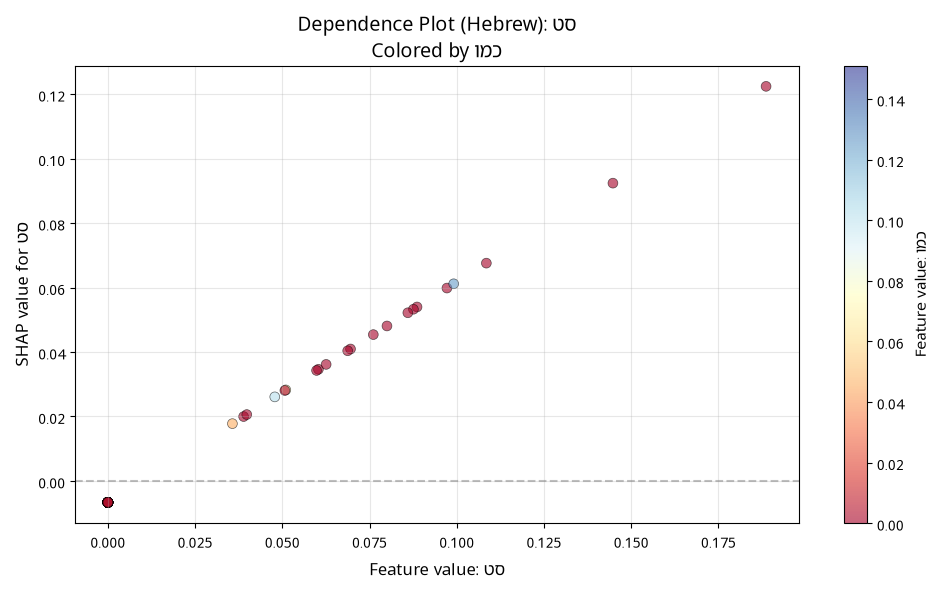


📊 ENGLISH DEPENDENCE PLOT

🎨 English Dependence Plot (Matplotlib)...


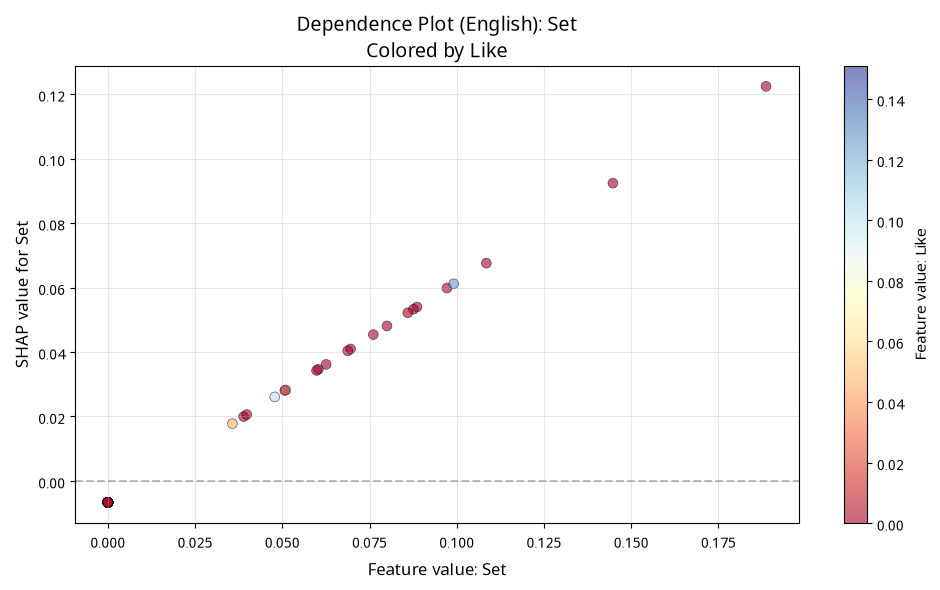


📊 EXPLANATION

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Hebrew Text:
  נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים

English Translation:
  It seems to me that the case reminds you of your good old days in the hills where you were a racist terrorist like them, isn't there a bit of nostalgia in hard times
--------------------------------------------------------------------------------

📝 Sample Translation:
   It seems to me that the case reminds you of your good old days in the hills where you were a racist terrorist like them, isn't there a bit of nostalgia in hard times
------------------------------------------------------------

📊 Feature: סט
   English: Set
   Mean SHAP: +0.0046
------------------------------------------------------------

📝 English Explanation:
   The Hebrew feature 'סט' (SHAP value: +0.0046) has a slight positive impact on the model's prediction of 'VIOLENCE', suggesting that the presence of t

In [9]:
# ============================================================
# HEBREW DEPENDENCE PLOT - WITH PROPER FEATURE NAME
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import dependence_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT - WITH PROPER FEATURE NAME")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES")
print("="*80)

# Get SHAP values for the sample
vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CREATE DEPENDENCE PLOT - WITH PROPER FEATURE NAME
# ============================================================

print("\n" + "="*80)
print("📊 CREATING DEPENDENCE PLOT WITH PROPER FEATURE NAME")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Selected feature:")
print(f"   Feature: '{top_feature}'")
print(f"   Feature index: {top_feature_idx}")
print(f"   SHAP value: {sorted_shap[0]:+.4f}")
print("-"*60)

# ============================================================
# STEP 9: CREATE DEPENDENCE PLOT DATA - CORRECTLY
# ============================================================

# Extract data for the SPECIFIC feature
feature_data = data_all[:, top_feature_idx]
feature_shap = shap_values_all[:, top_feature_idx]

# For coloring, use the second feature
color_data = data_all[:, second_feature_idx]

# Create a SHAP Explanation with ONLY the specific feature
# This ensures the feature name is correctly displayed
dependence_shap_single = shap.Explanation(
    values=feature_shap,  # 1D array for single feature
    base_values=np.mean(feature_shap),
    data=feature_data,  # 1D array
    feature_names=[top_feature]  # ← Feature name as a list!
)

print(f"\n📊 Dependence plot data:")
print(f"   Feature: {top_feature}")
print(f"   Data shape: {dependence_shap_single.data.shape}")
print(f"   Values shape: {dependence_shap_single.values.shape}")
print(f"   Feature names: {dependence_shap_single.feature_names}")
print("-"*60)

# ============================================================
# STEP 10: GENERATE DEPENDENCE PLOT - HEBREW FIRST
# ============================================================

print("\n" + "="*80)
print("📊 GENERATING DEPENDENCE PLOT - HEBREW")
print("="*80)

print("\n📋 The dependence plot will show:")
print(f"   • Feature: '{top_feature}' (in Hebrew)")
print("   • X-axis: Feature values")
print("   • Y-axis: SHAP values")
print("   • Color: Second feature value")
print("-"*60)

# Use run_full_analysis with dependence_plot
# Pass the single-feature SHAP Explanation
# This will show the Hebrew feature name correctly!
try:
    explainer_rtl.run_full_analysis(
        shap_values=dependence_shap_single,  # ← Single feature only!
        prediction_label=class_names[1],
        plot_fn=dependence_plot,
        max_features=1,
        sample_text=sample_text,
        features=feature_data  # ← Pass feature data
    )
except Exception as e:
    print(f"[WARNING] Dependence plot via explainer failed: {e}")
    print("\n📌 Using direct matplotlib fallback...")
    
    # ============================================================
    # FALLBACK: Direct Dependence Plot with Matplotlib
    # ============================================================
    
    # Translate feature names for display
    top_feature_eng = explainer_rtl._translate_features([top_feature])[0]
    second_feature_eng = explainer_rtl._translate_features([second_feature])[0]
    
    # ── HEBREW DEPENDENCE PLOT ──────────────────────────────────────────────
    print("\n🎨 Hebrew Dependence Plot (Matplotlib)...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create scatter plot
    scatter = ax.scatter(
        feature_data,
        feature_shap,
        c=color_data,
        cmap='RdYlBu',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )
    
    # Hebrew labels
    ax.set_xlabel(f'Feature value: {top_feature}', fontsize=12)
    ax.set_ylabel(f'SHAP value for {top_feature}', fontsize=12)
    ax.set_title(f'Dependence Plot (Hebrew): {top_feature}\nColored by {second_feature}', 
                 fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter)
    cbar.set_label(f'Feature value: {second_feature}', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # ── ASK FOR ENGLISH ──────────────────────────────────────────────────────
    print("\n" + "="*80)
    print("📊 ENGLISH DEPENDENCE PLOT")
    print("="*80)
    
    choice = input("\nWould you like to see the plot in English? (Yes/No): ").strip().lower()
    
    if choice in ["yes", "y"]:
        print("\n🎨 English Dependence Plot (Matplotlib)...")
        fig, ax = plt.subplots(figsize=(10, 6))
        
        scatter = ax.scatter(
            feature_data,
            feature_shap,
            c=color_data,
            cmap='RdYlBu',
            alpha=0.6,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
        
        # English labels
        ax.set_xlabel(f'Feature value: {top_feature_eng}', fontsize=12)
        ax.set_ylabel(f'SHAP value for {top_feature_eng}', fontsize=12)
        ax.set_title(f'Dependence Plot (English): {top_feature_eng}\nColored by {second_feature_eng}', 
                     fontsize=14, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter)
        cbar.set_label(f'Feature value: {second_feature_eng}', fontsize=11)
        
        plt.tight_layout()
        plt.show()
    
    # ── ASK FOR EXPLANATION ──────────────────────────────────────────────────
    choice2 = input("\nWould you like explanation in English? (Yes/No): ").strip().lower()
    
    if choice2 in ["yes", "y"]:
        print("\n" + "="*80)
        print("📊 EXPLANATION")
        print("="*80)
        
        eng_sample = explainer_rtl._translate_sample(sample_text)
        eng_label = explainer_rtl._translate_label(class_names[1])
        eng_feature = explainer_rtl._translate_features([top_feature])[0]
        
        print(f"\n📝 Sample Translation:")
        print(f"   {eng_sample}")
        print("-"*60)
        
        print(f"\n📊 Feature: {top_feature}")
        print(f"   English: {eng_feature}")
        print(f"   Mean SHAP: {np.mean(feature_shap):+.4f}")
        print("-"*60)
        
        try:
            prompt = explainer_rtl._eng_prompt(
                feat_name=top_feature,
                shap_val=np.mean(feature_shap),
                prediction_label=class_names[1],
                eng_translation=eng_label
            )
            response = explainer_rtl._invoke_llm(prompt)
            print(f"\n📝 English Explanation:")
            print(f"   {response}")
        except Exception as e:
            print(f"   Could not generate explanation: {e}")

# ============================================================
# STEP 11: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation
correlation = np.corrcoef(feature_data, feature_shap)[0, 1]

print(f"\n📊 Feature: '{top_feature}'")
print(f"   Correlation with SHAP: {correlation:.3f}")
print(f"   Mean SHAP value: {np.mean(feature_shap):+.4f}")
print(f"   Positive SHAP in {np.mean(feature_shap > 0)*100:.1f}% of samples")

if correlation > 0.3:
    print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
elif correlation < -0.3:
    print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
else:
    print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")

# Class-wise analysis
violence_shap = feature_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap = feature_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

if len(violence_shap) > 0 and len(not_shap) > 0:
    print(f"\n📊 Class-wise Analysis:")
    print(f"   VIOLENCE samples: {np.mean(violence_shap):+.4f} (n={len(violence_shap)})")
    print(f"   NOT samples:      {np.mean(not_shap):+.4f} (n={len(not_shap)})")
    
    if np.mean(violence_shap) > np.mean(not_shap):
        print(f"   ✅ Feature is more positive in VIOLENCE samples")
    else:
        print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ DEPENDENCE PLOT ANALYSIS COMPLETE!")
print("="*80)